GOLD RETURNS

In [1]:
#Imports libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

#FetchING daily gold futures prices (in USD) from Yahoo Finance between 2015 and 2025.
gold = yf.download("GC=F", start="2015-01-01", end="2025-12-31")

#Downloading the USD to INR exchange rate for the same period
inr = yf.download("INR=X", start="2015-01-01", end="2025-12-31")

#Merging the two datasets by date and calculating gold’s price in INR
data = pd.merge(gold[['Close']], inr[['Close']], left_index=True, right_index=True, suffixes=('_GoldUSD', '_INR'))
data['Gold_INR'] = data[('Close', 'GC=F')] * data[('Close', 'INR=X')]

# Converting daily data into month-end observations by taking the last available price each month.
data_monthly = data.resample('ME').last().reset_index()
data_monthly.rename(columns={'Gold_INR': 'Close_Gold_INR'}, inplace=True)

# Computing monthly percentage returns on gold prices in INR using the percent change from one month to the next.
data_monthly['Return_Gold'] = data_monthly['Close_Gold_INR'].pct_change() * 100

# Flattening any multi-level column names into simple single-line names for easier handling.
data_monthly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data_monthly.columns]

# Cleaning the column header so that the first column is properly named ‘Date’.
if 'Date_' in data_monthly.columns[0]:
    data_monthly.rename(columns={data_monthly.columns[0]: 'Date'}, inplace=True)

# Keeping only the columns relevant for analysis
data_monthly = data_monthly[['Date', 'Close_Gold_INR_', 'Return_Gold_']]


/tmp/ipython-input-3439313185.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2015-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-3439313185.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  inr = yf.download("INR=X", start="2015-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


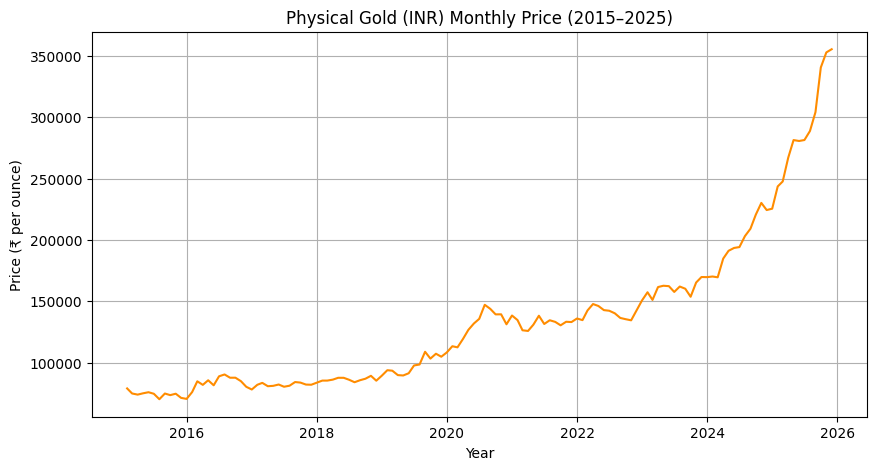

In [2]:

#line chart showing how the INR price of gold has moved over time from 2015 to 2025.
plt.figure(figsize=(10,5))
plt.plot(data_monthly['Date'], data_monthly['Close_Gold_INR_'], color='darkorange')
plt.title('Physical Gold (INR) Monthly Price (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Price (₹ per ounce)')
plt.grid(True)
plt.show()

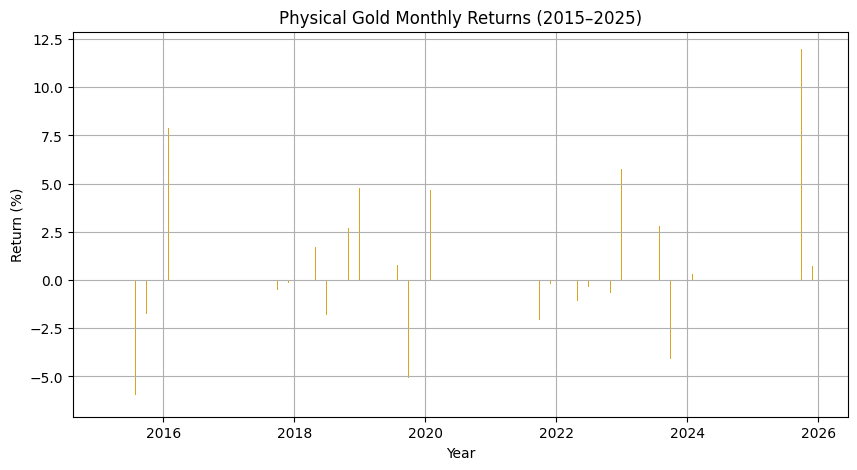

In [3]:
# monthly returns
plt.figure(figsize=(10,5))
plt.bar(data_monthly['Date'], data_monthly['Return_Gold_'], color='goldenrod')
plt.title('Physical Gold Monthly Returns (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Return (%)')
plt.grid(True)
plt.show()

SGB

Saving SGB_BSE_2015_2025.xlsx to SGB_BSE_2015_2025.xlsx


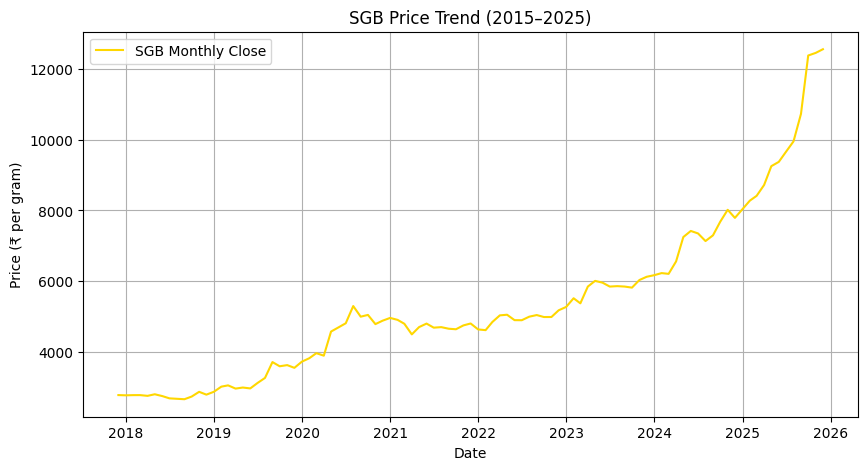

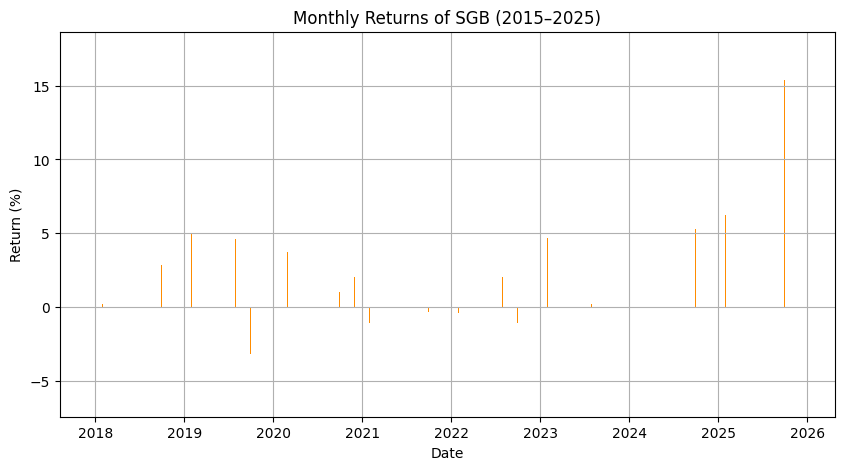

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Uploading Excel file
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('SGB_BSE_2015_2025.xlsx')

# Cleaning data
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Converting 'Date' to end of month to match ETF and Gold data
df['Date'] = df['Date'] + pd.offsets.MonthEnd(0)
df = df.sort_values('Date')

# Selecting the correct column names (Open, High, Low, Close) which are already present
df = df[['Date', 'Open', 'High', 'Low', 'Close']]

# Calculating monthly returns
df['Return'] = df['Close'].pct_change() * 100

# Plotting trend
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'], label='SGB Monthly Close', color='gold')
plt.title('SGB Price Trend (2015–2025)')
plt.xlabel('Date')
plt.ylabel('Price (₹ per gram)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting returns
plt.figure(figsize=(10,5))
plt.bar(df['Date'], df['Return'], color='darkorange')
plt.title('Monthly Returns of SGB (2015–2025)')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.grid(True)
plt.show()

ETF

/tmp/ipython-input-58779578.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf = yf.download("NIFTYBEES.NS", start="2015-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


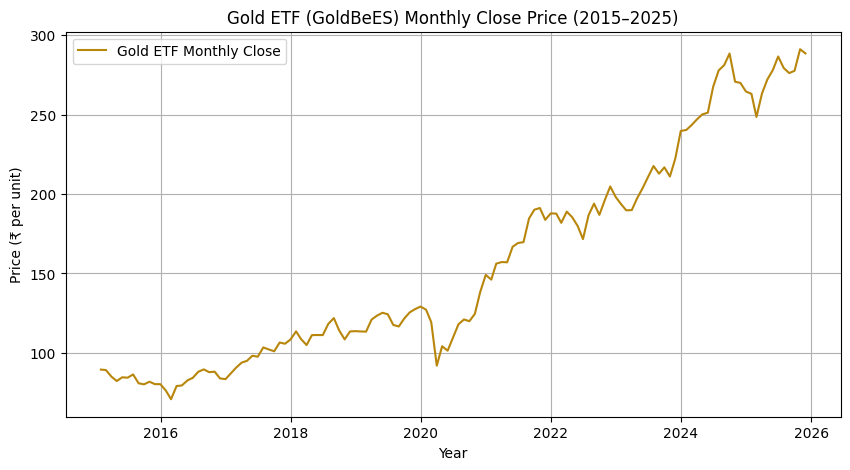

In [5]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Downloading Nippon India GoldBees ETF data from 2015–2025
etf = yf.download("NIFTYBEES.NS", start="2015-01-01", end="2025-12-31")

# Keeping only relevant columns and computing monthly averages
etf = etf[['Close']]
etf.index = pd.to_datetime(etf.index)
etf_monthly = etf.resample('ME').last().reset_index()

# Flattening MultiIndex columns to single level
etf_monthly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in etf_monthly.columns]

#Renaming columns for consistency
if 'Date_' in etf_monthly.columns:
    etf_monthly.rename(columns={'Date_': 'Date'}, inplace=True)

etf_monthly.rename(columns={'Close_NIFTYBEES.NS': 'Close_ETF'}, inplace=True)

# Calculating monthly returns
etf_monthly['Return_ETF'] = etf_monthly['Close_ETF'].pct_change() * 100

# Plotting price trend
plt.figure(figsize=(10,5))
plt.plot(etf_monthly['Date'], etf_monthly['Close_ETF'], color='darkgoldenrod', label='Gold ETF Monthly Close') # Added label here
plt.title('Gold ETF (GoldBeES) Monthly Close Price (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Price (₹ per unit)')
plt.legend() # Now this will show a legend
plt.grid(True)
plt.show()


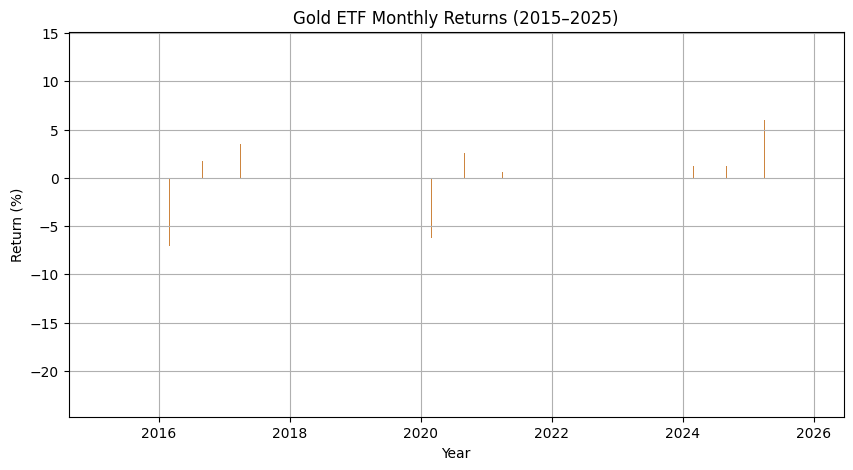

In [6]:
# Plotting monthly returns
plt.figure(figsize=(10,5))
plt.bar(etf_monthly['Date'], etf_monthly['Return_ETF'], color='peru')
plt.title('Gold ETF Monthly Returns (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Return (%)')
plt.grid(True)
plt.show()


COMBINED ANALYSIS

In [7]:
# Merging all datasets on Date
sgb_data = df[['Date', 'Return']].rename(columns={'Return': 'Return_SGB'})
etf_data = etf_monthly[['Date', 'Return_ETF']]
# Ensuring etf_data columns are flat
etf_data.columns = [col[0] if isinstance(col, tuple) else col for col in etf_data.columns]
gold_data = data_monthly[['Date', 'Return_Gold_']]

merged = pd.merge(sgb_data, etf_data, on='Date', how='outer')
merged = pd.merge(merged, gold_data, on='Date', how='outer')
merged = merged.dropna().reset_index(drop=True)

merged.head()

,Date,Return_SGB,Return_ETF,Return_Gold_
0,2017-12-31,-0.251166,2.555175,2.037808
1,2018-01-31,0.197842,4.699027,2.035879
2,2018-02-28,0.017950,-4.292610,0.001419
3,2018-03-31,-0.746949,-3.446209,0.925476
4,2018-04-30,1.620503,5.949960,1.732101


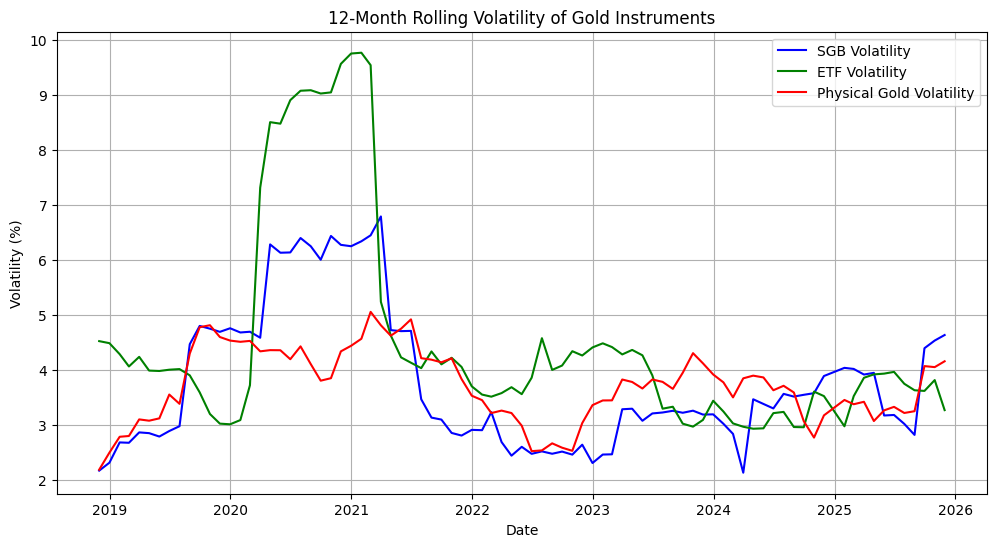

In [8]:
import matplotlib.pyplot as plt

# Calculating rolling 12-month volatility for all three instruments
merged['Rolling_Volatility_SGB'] = merged['Return_SGB'].rolling(window=12).std()
merged['Rolling_Volatility_ETF'] = merged['Return_ETF'].rolling(window=12).std()
merged['Rolling_Volatility_Gold'] = merged['Return_Gold_'].rolling(window=12).std()

# Plotting the rolling volatilities on a single graph
plt.figure(figsize=(12, 6))
plt.plot(merged['Date'], merged['Rolling_Volatility_SGB'], label='SGB Volatility', color='blue')
plt.plot(merged['Date'], merged['Rolling_Volatility_ETF'], label='ETF Volatility', color='green')
plt.plot(merged['Date'], merged['Rolling_Volatility_Gold'], label='Physical Gold Volatility', color='red')

plt.title('12-Month Rolling Volatility of Gold Instruments')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
#MERGING DATA

In [11]:
# IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
!pip install statsmodels --quiet
from statsmodels.tsa.stattools import adfuller # Corrected import from stattool to stattools
from statsmodels.stats.diagnostic import het_arch

# DATA CLEANING

data_monthly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data_monthly.columns]
if 'Date_' in data_monthly.columns[0]:
    data_monthly.rename(columns={data_monthly.columns[0]: 'Date'}, inplace=True)
data_monthly = data_monthly[['Date', 'Close_Gold_INR_', 'Return_Gold_']]

sgb_data = df[['Date', 'Return']].rename(columns={'Return': 'Return_SGB'})
etf_data = etf_monthly[['Date', 'Return_ETF']]
gold_data = data_monthly[['Date', 'Return_Gold_']]

# Merging all data on Date
merged = pd.merge(sgb_data, etf_data, on='Date', how='outer')
merged = pd.merge(merged, gold_data, on='Date', how='outer')
merged = merged.dropna().reset_index(drop=True)

print("Data merged successfully — shape:", merged.shape)


Data merged successfully — shape: (95, 4)



=== Correlation Matrix ===
              Return_SGB  Return_ETF  Return_Gold_
Return_SGB      1.000000    0.044439      0.713366
Return_ETF      0.044439    1.000000     -0.131777
Return_Gold_    0.713366   -0.131777      1.000000


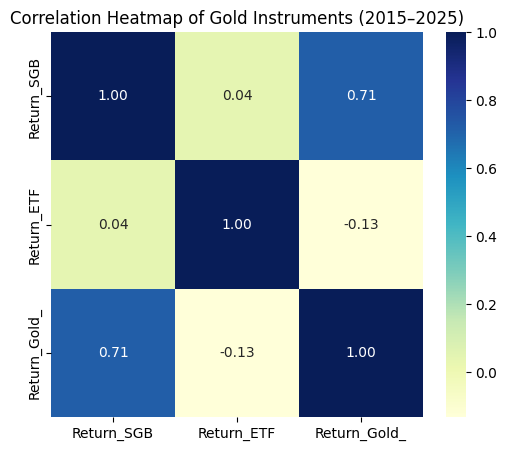

In [12]:
# CORRELATION MATRIX ---
corr = merged[['Return_SGB', 'Return_ETF', 'Return_Gold_']].corr()
print("\n=== Correlation Matrix ===")
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Heatmap of Gold Instruments (2015–2025)")
plt.show()

In [13]:
# ADF TEST (Stationarity) ---
def adf(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: p-value = {result[1]:.4f} → ", "Stationary ✅" if result[1]<0.05 else "Non-stationary ❌")

print("\n=== Augmented Dickey-Fuller (ADF) Test ===")
adf(merged['Return_SGB'], "SGB Returns")
adf(merged['Return_ETF'], "ETF Returns")
adf(merged['Return_Gold_'], "Gold Returns")


=== Augmented Dickey-Fuller (ADF) Test ===
SGB Returns: p-value = 0.0000 →  Stationary ✅
ETF Returns: p-value = 0.0000 →  Stationary ✅
Gold Returns: p-value = 0.0000 →  Stationary ✅


REGRESSION ANALYSIS

In [14]:
# ETF vs Gold
X2 = sm.add_constant(merged['Return_Gold_'])
model_etf = sm.OLS(merged['Return_ETF'], X2).fit()

print("\n=== Regression Results: ETF on Gold ===")
print(model_etf.summary())


=== Regression Results: ETF on Gold ===
                            OLS Regression Results                            
Dep. Variable:             Return_ETF   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.644
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.203
Time:                        17:49:50   Log-Likelihood:                -281.07
No. Observations:                  95   AIC:                             566.1
Df Residuals:                      93   BIC:                             571.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const  

In [15]:

# SGB vs Gold
X1 = sm.add_constant(merged['Return_Gold_'])
model_sgb = sm.OLS(merged['Return_SGB'], X1).fit()

print("\n=== Regression Results: SGB on Gold ===")
print(model_sgb.summary())





=== Regression Results: SGB on Gold ===
                            OLS Regression Results                            
Dep. Variable:             Return_SGB   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     96.37
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           5.00e-16
Time:                        17:49:54   Log-Likelihood:                -233.58
No. Observations:                  95   AIC:                             471.2
Df Residuals:                      93   BIC:                             476.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const  

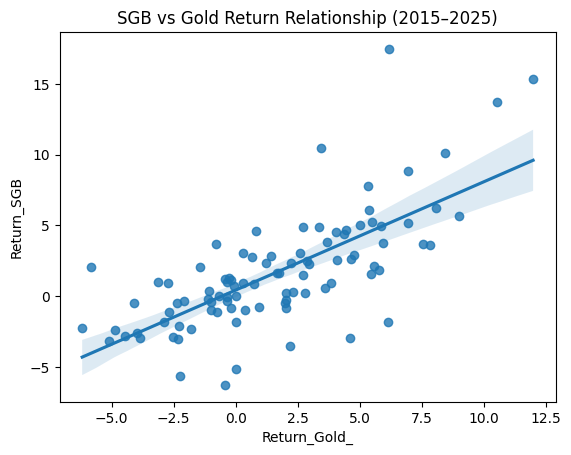

In [16]:
# RELATIONSHIP PLOTS
sns.regplot(x=merged['Return_Gold_'], y=merged['Return_SGB'])
plt.title("SGB vs Gold Return Relationship (2015–2025)")
plt.show()



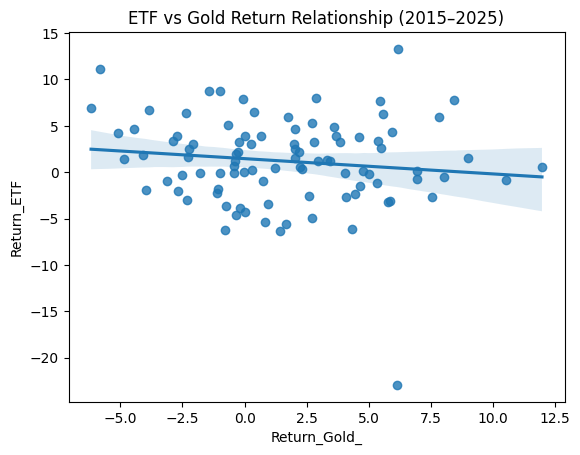

In [17]:
sns.regplot(x=merged['Return_Gold_'], y=merged['Return_ETF'])
plt.title("ETF vs Gold Return Relationship (2015–2025)")
plt.show()


=== ARCH (Heteroskedasticity) Test ===
Return_SGB: p-value = 0.3303 →  No clustering ❌
Return_ETF: p-value = 0.1884 →  No clustering ❌
Return_Gold_: p-value = 0.8734 →  No clustering ❌


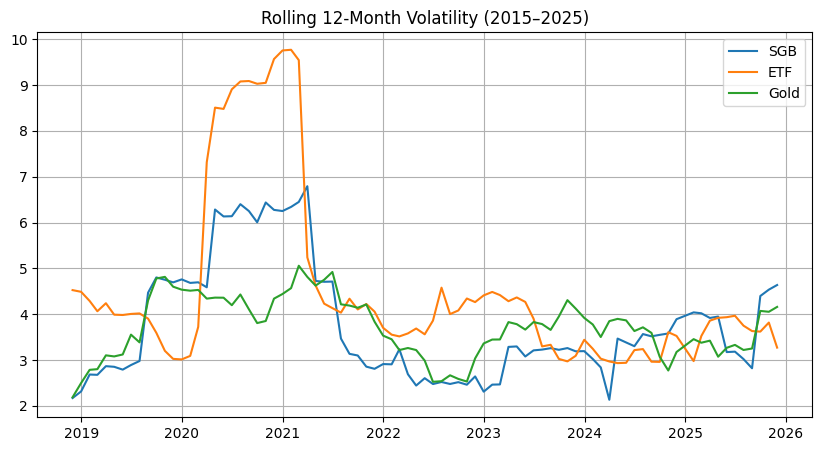


 Analysis complete.


In [18]:
# ARCH TEST (Volatility Clustering)
print("\n=== ARCH (Heteroskedasticity) Test ===")
for col in ['Return_SGB', 'Return_ETF', 'Return_Gold_']:
    test_stat, p_value, _, _ = het_arch(merged[col].dropna())
    print(f"{col}: p-value = {p_value:.4f} → ", "Volatility clustering ✅" if p_value<0.05 else "No clustering ❌")

# ROLLING VOLATILITY
plt.figure(figsize=(10,5))
plt.plot(merged['Date'], merged['Return_SGB'].rolling(12).std(), label='SGB')
plt.plot(merged['Date'], merged['Return_ETF'].rolling(12).std(), label='ETF')
plt.plot(merged['Date'], merged['Return_Gold_'].rolling(12).std(), label='Gold')
plt.title("Rolling 12-Month Volatility (2015–2025)")
plt.legend()
plt.grid(True)
plt.show()

print("\n Analysis complete.")

In [23]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
from google.colab import files # Import files module
import yfinance as yf # Needed for etf_monthly and data_monthly

should_reprocess_df = False
if 'df' not in locals():
    print("DataFrame 'df' not found, need to load and process.")
    should_reprocess_df = True
elif 'Return' not in df.columns:
    print("DataFrame 'df' found but 'Return' column is missing, re-processing.")
    should_reprocess_df = True
else:
    print("DataFrame 'df' found with 'Return' column. Skipping re-processing of df.")

if should_reprocess_df:
    print("Please upload 'SGB_BSE_2015_2025.xlsx' or 'SGB_BSE_2015_2025 (2).xlsx' if prompted.")
    if 'df' not in locals() or 'uploaded' not in locals():
        try:
            uploaded = files.upload()
        except Exception as e:
            print(f"File upload cancelled or failed: {e}. Attempting to read from existing files.")


    try:
        df = pd.read_excel('SGB_BSE_2015_2025.xlsx')
    except FileNotFoundError:
        print("Original filename not found, trying 'SGB_BSE_2015_2025 (2).xlsx'...")
        df = pd.read_excel('SGB_BSE_2015_2025 (2).xlsx')

    # Clean
    df.columns = df.columns.str.strip()


    if 'Month' in df.columns:
        df['Date'] = pd.to_datetime(df['Month'], format='%b-%y', errors='coerce')
    elif 'Date' in df.columns:

        df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    else:
        raise KeyError("Neither 'Month' nor 'Date' column found in the Excel file for SGB data.")

    # Convert 'Date' to end of month to match ETF and Gold data
    df['Date'] = df['Date'] + pd.offsets.MonthEnd(0)
    df = df.sort_values('Date')

    df = df[['Date', 'Open', 'High', 'Low', 'Close']]

    # monthly returns
    df['Return'] = df['Close'].pct_change() * 100
    print("SGB data (df) re-processed successfully with 'Return' column.")

# Ensure etf_monthly is defined and has 'Return_ETF'
if 'etf_monthly' not in locals() or 'Return_ETF' not in etf_monthly.columns:
    print("etf_monthly not found or 'Return_ETF' missing, recreating/updating...")
    if 'etf_monthly' not in locals():
        etf = yf.download("GOLDBEES.NS", start="2015-01-01", end="2025-12-31")
        etf = etf[['Close']]
        etf.index = pd.to_datetime(etf.index)
        etf_monthly = etf.resample('ME').last().reset_index()
        etf_monthly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in etf_monthly.columns]
        if 'Date_' in etf_monthly.columns:
            etf_monthly.rename(columns={'Date_': 'Date'}, inplace=True)
        etf_monthly.rename(columns={'Close_GOLDBEES.NS': 'Close_ETF'}, inplace=True)

    if 'Return_ETF' not in etf_monthly.columns:
        etf_monthly['Return_ETF'] = etf_monthly['Close_ETF'].pct_change() * 100

# Ensure data_monthly is defined and has 'Return_Gold_'
if 'data_monthly' not in locals() or 'Return_Gold_' not in data_monthly.columns:
    print("data_monthly not found or 'Return_Gold_' missing, recreating/updating...")
    if 'data_monthly' not in locals():
        gold = yf.download("GC=F", start="2015-01-01", end="2025-12-31")
        inr = yf.download("INR=X", start="2015-01-01", end="2025-12-31")
        data = pd.merge(gold[['Close']], inr[['Close']], left_index=True, right_index=True, suffixes=('_GoldUSD', '_INR'))
        data['Gold_INR'] = data[('Close', 'GC=F')] * data[('Close', 'INR=X')]
        data_monthly = data.resample('ME').last().reset_index()
        data_monthly.rename(columns={'Gold_INR': 'Close_Gold_INR'}, inplace=True)
        data_monthly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in data_monthly.columns]
        if 'Date_' in data_monthly.columns[0]:
            data_monthly.rename(columns={data_monthly.columns[0]: 'Date'}, inplace=True)

    if 'Return_Gold_' not in data_monthly.columns:
        data_monthly['Return_Gold_'] = data_monthly['Close_Gold_INR_'].pct_change() * 100
    data_monthly = data_monthly[['Date', 'Close_Gold_INR_', 'Return_Gold_']]



# Clean and select needed columns
sgb_data = df[['Date', 'Return']].rename(columns={'Return': 'Return_SGB'})
etf_data = etf_monthly[['Date', 'Return_ETF']]
gold_data = data_monthly[['Date', 'Return_Gold_']]

# Merge all on Date
merged = pd.merge(sgb_data, etf_data, on='Date', how='outer')
merged = pd.merge(merged, gold_data, on='Date', how='outer')
merged = merged.dropna().reset_index(drop=True)

# Select relevant columns for Granger Causality
gc_data = merged[['Return_Gold_', 'Return_SGB', 'Return_ETF']].dropna()

print("\n=== Granger Causality Test (Does Gold Predict SGB?) ===")
granger_sgb = grangercausalitytests(gc_data[['Return_SGB', 'Return_Gold_']], maxlag=3, verbose=True)

print("\n=== Granger Causality Test (Does Gold Predict ETF?) ===")
granger_etf = grangercausalitytests(gc_data[['Return_ETF', 'Return_Gold_']], maxlag=3, verbose=True)

DataFrame 'df' found with 'Return' column. Skipping re-processing of df.

=== Granger Causality Test (Does Gold Predict SGB?) ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.8006  , p=0.0310  , df_denom=91, df_num=1
ssr based chi2 test:   chi2=4.9588  , p=0.0260  , df=1
likelihood ratio test: chi2=4.8325  , p=0.0279  , df=1
parameter F test:         F=4.8006  , p=0.0310  , df_denom=91, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.0273  , p=0.0535  , df_denom=88, df_num=2
ssr based chi2 test:   chi2=6.3986  , p=0.0408  , df=2
likelihood ratio test: chi2=6.1881  , p=0.0453  , df=2
parameter F test:         F=3.0273  , p=0.0535  , df_denom=88, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.2465  , p=0.0887  , df_denom=85, df_num=3
ssr based chi2 test:   chi2=7.2946  , p=0.0631  , df=3
likelihood ratio test: chi2=7.0198  , p=0.0713  , df=3
parameter F test:         F=2.2465  , p=0.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [21]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Prepare data — use price levels, not returns

price_data = merged[['Return_SGB', 'Return_ETF', 'Return_Gold_']].dropna().copy()

# Reconstruct price indices
price_data = (1 + price_data/100).cumprod()
price_data.columns = ['SGB_Price_Index', 'ETF_Price_Index', 'Gold_Price_Index']

# Johansen cointegration test
johansen_test = coint_johansen(price_data, det_order=0, k_ar_diff=2)

# Display trace statistics and critical values
print("\n=== Johansen Cointegration Test Results ===")
for i in range(len(johansen_test.lr1)):
    print(f"Rank {i}: Trace Stat = {johansen_test.lr1[i]:.4f}, 5% Critical Value = {johansen_test.cvt[i, 1]:.4f}")

# Eigenvalues (strength of cointegration)
print("\nEigenvalues:", johansen_test.eig)


=== Johansen Cointegration Test Results ===
Rank 0: Trace Stat = 39.9338, 5% Critical Value = 29.7961
Rank 1: Trace Stat = 16.7759, 5% Critical Value = 15.4943
Rank 2: Trace Stat = 2.6464, 5% Critical Value = 3.8415

Eigenvalues: [0.22253467 0.14236933 0.02835571]


#DESCRIPTIVE STATISTICS

In [22]:
# Descriptive stats of Physical Gold
print("Descriptive Statistics for Physical Gold (2015–2025):")
print(data_monthly['Return_Gold_'].describe())

# Summary statistics for ETF
print("Descriptive Statistics for Gold ETF (2015–2025):")
print(etf_monthly['Return_ETF'].describe())

# Descriptive statistics for SGB
print("Descriptive Statistics for SGB (2015–2025):")
print(df['Return'].describe())

# DESCRIPTIVE SUMMARY
print("\n=== Descriptive Summary (Monthly Returns 2015–2025) ===")
print(merged[['Return_SGB', 'Return_ETF', 'Return_Gold_']].describe())



Descriptive Statistics for Physical Gold (2015–2025):
count    130.000000
mean       1.238802
std        3.929117
min       -6.180630
25%       -1.608101
50%        0.769514
75%        3.995971
max       11.972686
Name: Return_Gold_, dtype: float64
Descriptive Statistics for Gold ETF (2015–2025):
count    130.000000
mean       1.007642
std        4.507204
min      -22.927319
25%       -1.457771
50%        0.922868
75%        3.859410
max       13.313028
Name: Return_ETF, dtype: float64
Descriptive Statistics for SGB (2015–2025):
count    95.000000
mean      1.674241
std       4.057667
min      -6.250000
25%      -0.790141
50%       1.010101
75%       3.665173
max      17.466017
Name: Return, dtype: float64

=== Descriptive Summary (Monthly Returns 2015–2025) ===
       Return_SGB  Return_ETF  Return_Gold_
count   95.000000   95.000000     95.000000
mean     1.674241    1.197759      1.620045
std      4.057667    4.728950      3.782249
min     -6.250000  -22.927319     -6.180630
25%    